In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import randint, uniform

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [2]:
train_path = "/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv"
test_path = "/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

Training shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print("Training Information:")
train_df.info()
print("Missing values:")
missing = train_df.isnull().sum().sort_values(ascending=False)

display(missing[missing > 0].head(20))

print("Duplicate rows:", train_df.duplicated().sum())

print("\nNumerical columns:", train_df.select_dtypes(include=np.number).shape[1])
print("Categorical columns:", train_df.select_dtypes(exclude=np.number).shape[1])

Training Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null  

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

Duplicate rows: 0

Numerical columns: 38
Categorical columns: 43


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


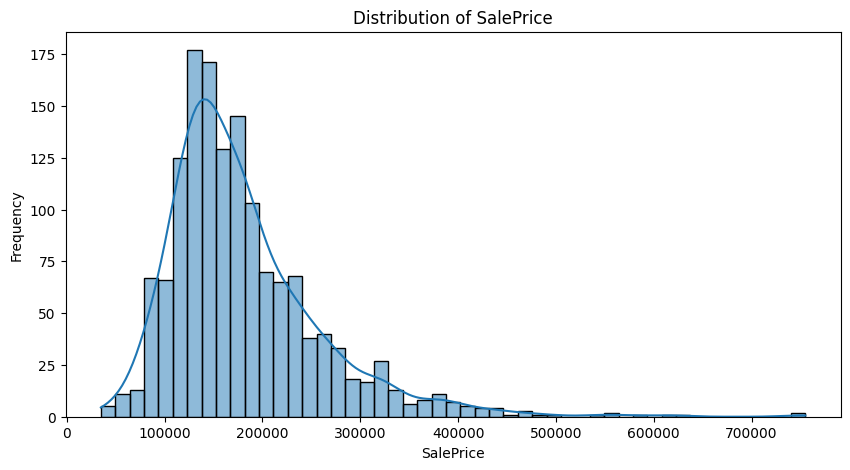

SalePrice Skewness: 1.8828757597682129


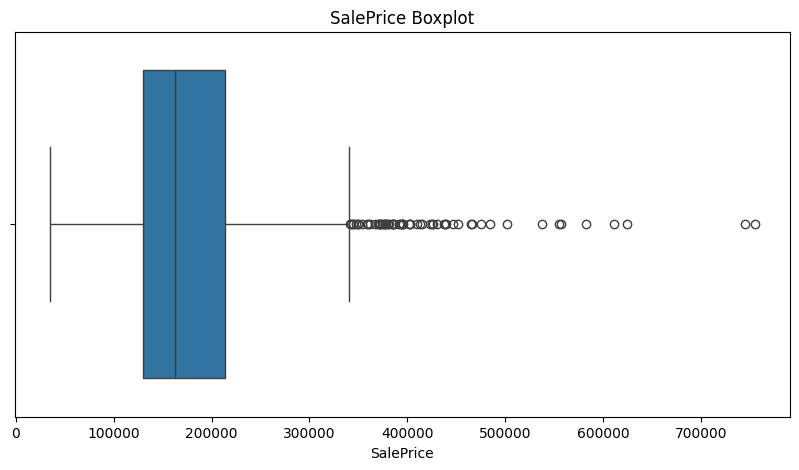

In [4]:
print(train_df["SalePrice"].describe())

plt.figure(figsize=(10, 5))

sns.histplot(train_df["SalePrice"], kde=True)

plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

print("SalePrice Skewness:", train_df["SalePrice"].skew())

plt.figure(figsize=(10, 5))

sns.boxplot(x=train_df["SalePrice"])

plt.title("SalePrice Boxplot")
plt.xlabel("SalePrice")
plt.show()


In [5]:
X = train_df.drop(columns=["SalePrice"])
y = train_df["SalePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1460, 80)
Target shape: (1460,)


In [6]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)

Training set: (1168, 80)
Validation set: (292, 80)


In [7]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 37
Categorical features: 43


In [8]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [9]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

In [10]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)


baseline_cv = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_mae = -baseline_cv["test_MAE"]
baseline_rmse = -baseline_cv["test_RMSE"]
baseline_r2 = baseline_cv["test_R2"]

print("Baseline Linear Regression")
print("-" * 40)

print(f"Mean CV MAE:  {baseline_mae.mean():,.2f}")
print(f"Std CV MAE:   {baseline_mae.std():,.2f}")

print(f"Mean CV RMSE: {baseline_rmse.mean():,.2f}")
print(f"Std CV RMSE:  {baseline_rmse.std():,.2f}")

print(f"Mean CV R²:   {baseline_r2.mean():.4f}")
print(f"Std CV R²:    {baseline_r2.std():.4f}")

Baseline Linear Regression
----------------------------------------
Mean CV MAE:  19,380.58
Std CV MAE:   1,007.38
Mean CV RMSE: 33,057.36
Std CV RMSE:  6,027.04
Mean CV R²:   0.8139
Std CV R²:    0.0553


In [11]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [12]:
rf_cv = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

rf_mae = -rf_cv["test_MAE"]
rf_rmse = -rf_cv["test_RMSE"]
rf_r2 = rf_cv["test_R2"]

print("Random Forest")
print("-" * 40)

print(f"Mean CV MAE:  {rf_mae.mean():,.2f}")
print(f"Std CV MAE:   {rf_mae.std():,.2f}")

print(f"Mean CV RMSE: {rf_rmse.mean():,.2f}")
print(f"Std CV RMSE:  {rf_rmse.std():,.2f}")

print(f"Mean CV R²:   {rf_r2.mean():.4f}")
print(f"Std CV R²:    {rf_r2.std():.4f}")

Random Forest
----------------------------------------
Mean CV MAE:  18,203.46
Std CV MAE:   1,104.54
Mean CV RMSE: 30,602.72
Std CV RMSE:  5,045.29
Mean CV R²:   0.8403
Std CV R²:    0.0443


In [13]:
param_distributions = {
    "model__n_estimators": randint(200, 800),
    
    "model__max_depth": [None, 10, 15, 20, 25, 30, 40],
    
    "model__min_samples_split": randint(2, 15),
    
    "model__min_samples_leaf": randint(1, 8),
    
    "model__max_features": [
        "sqrt",
        "log2",
        0.5,
        0.7,
        1.0
    ],
    
    "model__bootstrap": [True, False]
}


random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['Id',
                                                                                'MSSubClass',
                                                                                'LotFrontage',
                                                                                'LotArea',
                                                                                'OverallQual',
                                                                                'OverallCond',
                                                                                'YearBuilt',
                                                                                'YearRemodAdd',
                                                                                'MasVnrArea',
                                                                                'BsmtFinSF1',
                                                                                'BsmtFinSF2',...
                                        'model__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78322d5075f0>,
                                        'model__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78322d506a80>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78322d505a90>},
                   random_state=42, return_train_score=True,
                   scoring='neg_root_mean_squared_error', verbose=1)

In [14]:
print("Best Parameters:")
print(random_search.best_params_)

best_cv_rmse = -random_search.best_score_

print(f"Best Mean CV RMSE: {best_cv_rmse:,.2f}")

Best Parameters:
{'model__bootstrap': False, 'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 5, 'model__min_samples_split': 4, 'model__n_estimators': 220}
Best Mean CV RMSE: 29,984.51


In [15]:
cv_results = pd.DataFrame(random_search.cv_results_)

best_index = random_search.best_index_

best_mean_rmse = -cv_results.loc[
    best_index, "mean_test_score"
]

best_std_rmse = cv_results.loc[
    best_index, "std_test_score"
]

print("Best Tuned Model CV Results")
print("-" * 40)

print(f"Mean CV RMSE: {best_mean_rmse:,.2f}")
print(f"Std CV RMSE:  {best_std_rmse:,.2f}")
print("\nBest Parameters:")
print(random_search.best_params_)

Best Tuned Model CV Results
----------------------------------------
Mean CV RMSE: 29,984.51
Std CV RMSE:  4,169.33

Best Parameters:
{'model__bootstrap': False, 'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 5, 'model__min_samples_split': 4, 'model__n_estimators': 220}


In [16]:
final_model = random_search.best_estimator_

final_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Id', 'MSSubClass',
                                                   'LotFrontage', 'LotArea',
                                                   'OverallQual', 'OverallCond',
                                                   'YearBuilt', 'YearRemodAdd',
                                                   'MasVnrArea', 'BsmtFinSF1',
                                                   'BsmtFinSF2', 'BsmtUnfSF',
                                                   'TotalBsmtSF', '1stFlrSF',
                                                   '2ndFlrSF', 'LowQualFinSF',
                                                   'GrLivArea', 'Bsm...
                                                   'RoofMatl', 'Exterior1st',
                                                   'Exterior2nd', 'MasVnrType',
                                                   'ExterQual', 'ExterCond',
                                                   'Foundation', 'BsmtQual',
                                                   'BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir',
                                                   'Electrical', ...])])),
                ('model',
                 RandomForestRegressor(bootstrap=False, max_features=0.5,
                                       min_samples_leaf=5, min_samples_split=4,
                                       n_estimators=220, n_jobs=-1,
                                       random_state=42))])

In [17]:
import joblib

metadata = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "feature_names": X_train.columns.tolist(),
    "numeric_defaults": X_train[numeric_features].median().to_dict(),
    "categorical_defaults": X_train[categorical_features].mode().iloc[0].to_dict()
}

joblib.dump(
    final_model,
    "model.joblib"
)

joblib.dump(
    metadata,
    "metadata.joblib"
)

print("Model and metadata saved successfully.")

Model and metadata saved successfully.


In [18]:
y_pred = final_model.predict(X_valid)

print("Predictions generated:", len(y_pred))

Predictions generated: 292


In [19]:
def evaluate_model(model_name, y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    r2 = r2_score(y_true, predictions)
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

In [20]:
baseline_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_valid)
rf_pred = rf_model.predict(X_valid)
tuned_pred = final_model.predict(X_valid)

results = pd.DataFrame([
    evaluate_model(
        "Linear Regression",
        y_valid,
        baseline_pred
    ),
    
    evaluate_model(
        "Random Forest",
        y_valid,
        rf_pred
    ),
    
    evaluate_model(
        "Tuned Random Forest",
        y_valid,
        tuned_pred
    )
])

display(results.sort_values("RMSE"))

,Model,MAE,RMSE,R²
1,Random Forest,17465.290365,28554.982875,0.893696
2,Tuned Random Forest,17601.888615,29659.927065,0.885310
0,Linear Regression,20459.683261,31280.846361,0.872432


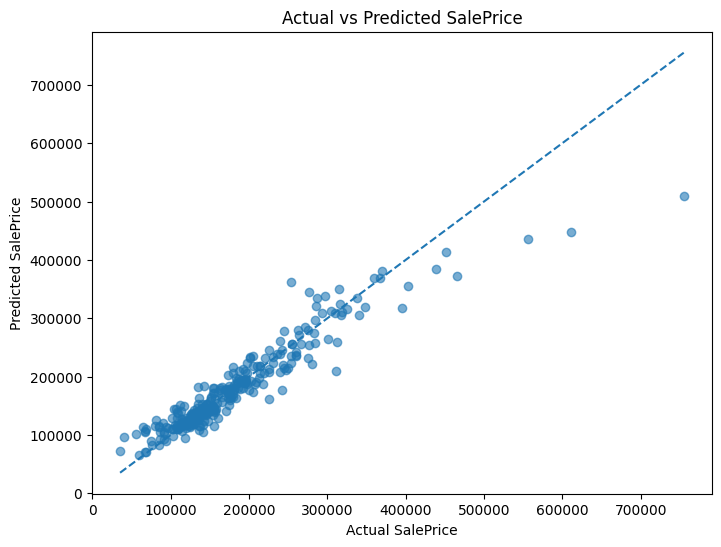

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_valid,
    tuned_pred,
    alpha=0.6
)

min_value = min(y_valid.min(), tuned_pred.min())
max_value = max(y_valid.max(), tuned_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted SalePrice")

plt.show()

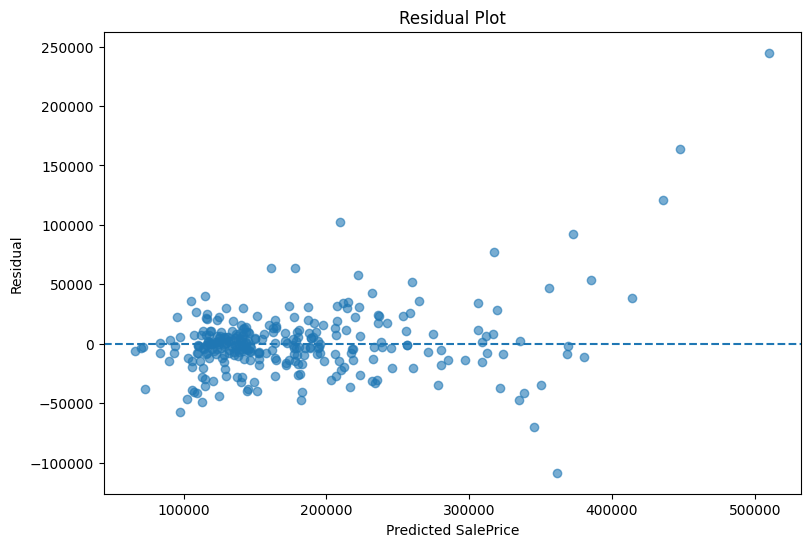

In [22]:
residuals = y_valid - tuned_pred

plt.figure(figsize=(9, 6))

plt.scatter(
    tuned_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

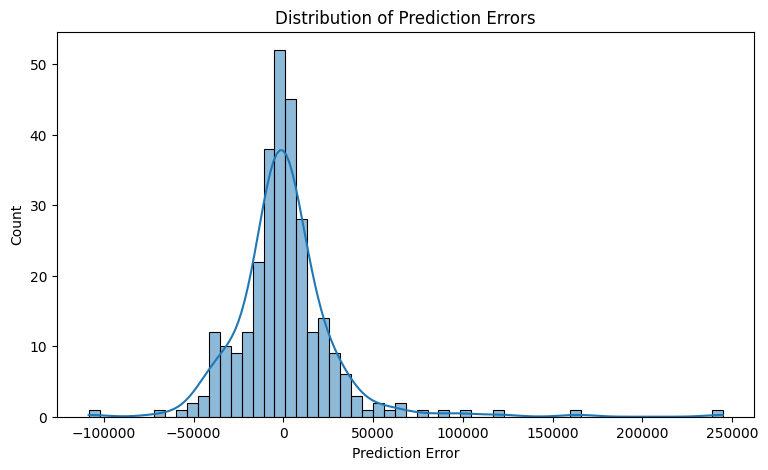

In [23]:
plt.figure(figsize=(9, 5))

sns.histplot(
    residuals,
    kde=True
)

plt.xlabel("Prediction Error")
plt.title("Distribution of Prediction Errors")

plt.show()

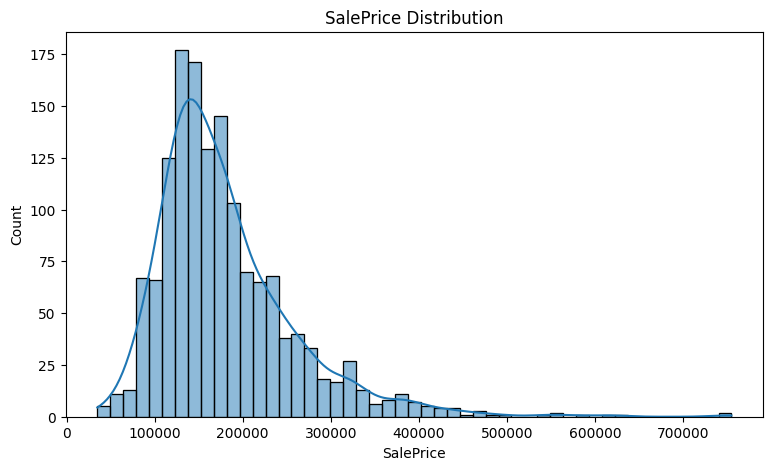

In [24]:
plt.figure(figsize=(9, 5))

sns.histplot(
    y,
    kde=True
)

plt.title("SalePrice Distribution")
plt.xlabel("SalePrice")

plt.show()

,Feature,Importance
4,num__OverallQual,0.390759
16,num__GrLivArea,0.129187
26,num__GarageCars,0.113754
169,cat__ExterQual_TA,0.060620
12,num__TotalBsmtSF,0.036933
6,num__YearBuilt,0.030883
13,num__1stFlrSF,0.025089
9,num__BsmtFinSF1,0.023977
27,num__GarageArea,0.018596
3,num__LotArea,0.015549


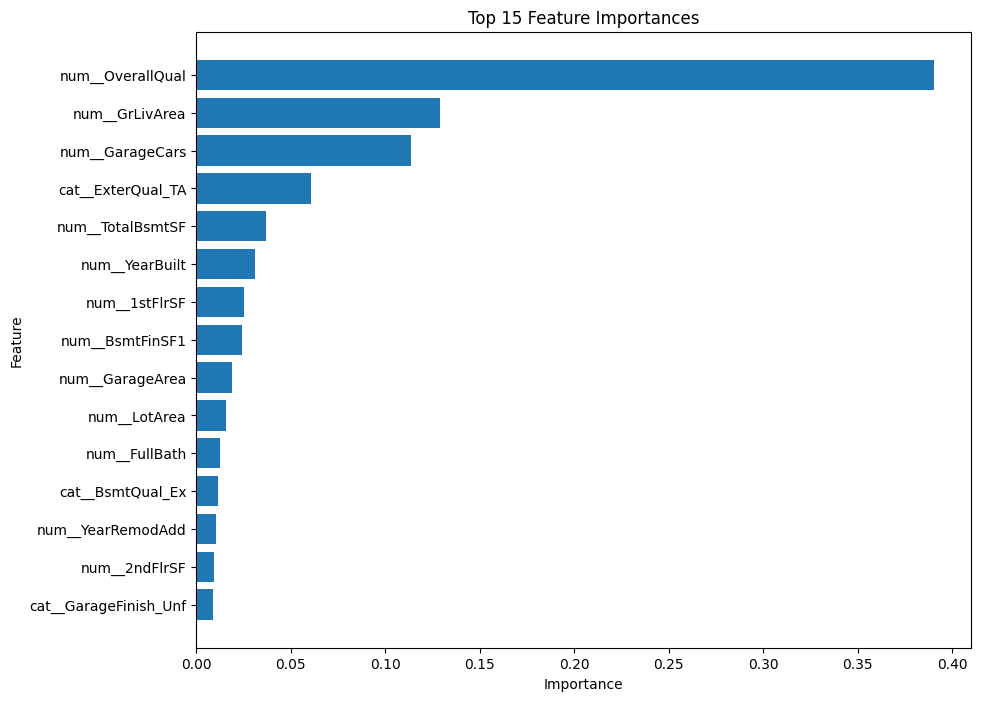

In [25]:
rf_estimator = final_model.named_steps["model"]
preprocessor_fitted = final_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

importances = rf_estimator.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance.head(20))

plt.figure(figsize=(10, 8))

top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.show()

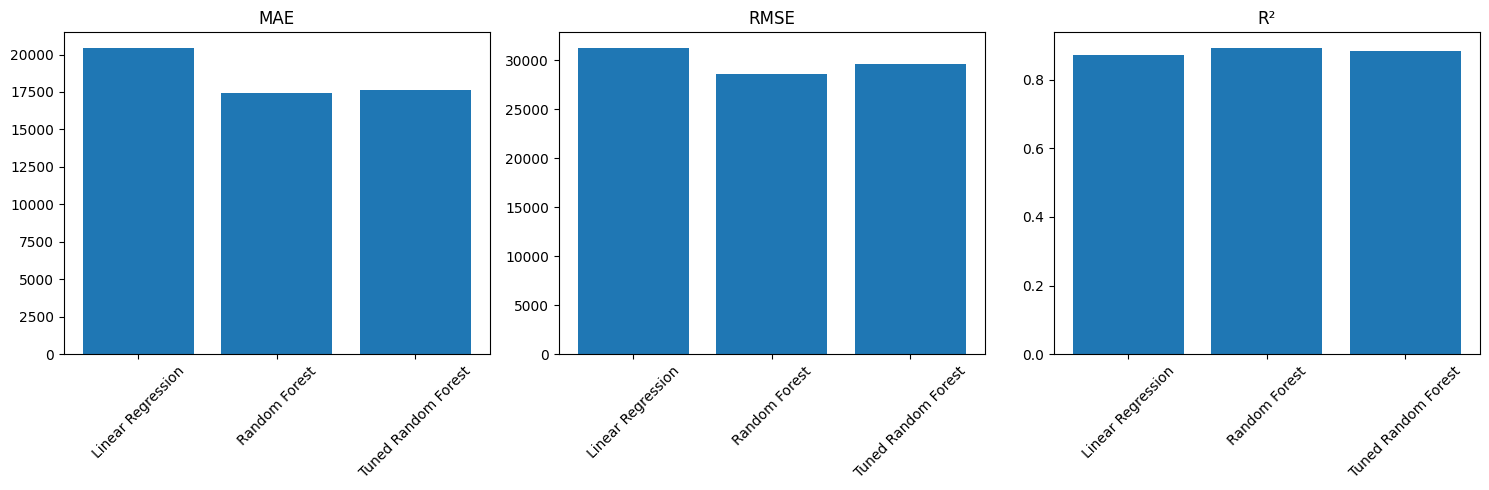

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ["MAE", "RMSE", "R²"]

for ax, metric in zip(axes, metrics):
    ax.bar(
        results["Model"],
        results[metric]
    )
    
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [27]:
best_model_row = results.loc[
    results["RMSE"].idxmin()
]

print("FINAL MODEL")
print("=" * 50)

print("Model:", best_model_row["Model"])
print(f"Validation MAE:  {best_model_row['MAE']:,.2f}")
print(f"Validation RMSE: {best_model_row['RMSE']:,.2f}")
print(f"Validation R²:   {best_model_row['R²']:.4f}")

print("\nRandomizedSearchCV")
print("-" * 50)
print(f"Mean CV RMSE: {best_mean_rmse:,.2f}")
print(f"Std CV RMSE:  {best_std_rmse:,.2f}")

print("\nBest Parameters:")
for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

FINAL MODEL
Model: Random Forest
Validation MAE:  17,465.29
Validation RMSE: 28,554.98
Validation R²:   0.8937

RandomizedSearchCV
--------------------------------------------------
Mean CV RMSE: 29,984.51
Std CV RMSE:  4,169.33

Best Parameters:
model__bootstrap: False
model__max_depth: None
model__max_features: 0.5
model__min_samples_leaf: 5
model__min_samples_split: 4
model__n_estimators: 220


In [28]:
test_predictions = final_model.predict(test_df)

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": test_predictions
})

submission.to_csv(
    "submission.csv",
    index=False
)

display(submission.head())

,Id,SalePrice
0,1461,127674.576308
1,1462,152938.446329
2,1463,177912.350225
3,1464,186528.264563
4,1465,203082.163344


In [29]:
import joblib

joblib.dump(
    final_model,
    "model.joblib"
)

print("Model saved successfully as model.joblib")

Model saved successfully as model.joblib
